# 04 — Eye State Custom CNN v2

## Objective

Improve the Custom CNN baseline for **Closed vs Open eye-state classification** while keeping the experiment independent from the MobileNetV2 model.



In [4]:
# 1. Imports and reproducibility

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Num GPUs:", len(tf.config.list_physical_devices("GPU")))


TensorFlow: 2.21.0
Num GPUs: 0


In [5]:
# 2. Paths and configuration

from pathlib import Path

# Automatically move from notebooks/ to the project root
PROJECT_ROOT = Path.cwd().parent

EYE_DATASET_DIR = PROJECT_ROOT / "eye_dataset"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 40

CLASS_NAMES = ["Closed", "Open"]
NUM_CLASSES = len(CLASS_NAMES)

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Eye dataset:", EYE_DATASET_DIR)
print("Model output:", MODEL_DIR)
print("Output directory:", OUTPUT_DIR)

if not EYE_DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Eye dataset not found: {EYE_DATASET_DIR}\n"
        "Please verify that eye_dataset exists in the project root."
    )

Current working directory: d:\driver-drowsiness-detection\notebooks
Project root: d:\driver-drowsiness-detection
Eye dataset: d:\driver-drowsiness-detection\eye_dataset
Model output: d:\driver-drowsiness-detection\models
Output directory: d:\driver-drowsiness-detection\outputs


## 3. Load the leakage-safe eye dataset




In [6]:
# 3. Load datasets

train_dir = EYE_DATASET_DIR / "train"
val_dir = EYE_DATASET_DIR / "validation"
test_dir = EYE_DATASET_DIR / "test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class names:", train_ds.class_names)


Found 1026 files belonging to 2 classes.
Found 212 files belonging to 2 classes.
Found 214 files belonging to 2 classes.
Class names: ['Closed', 'Open']


In [7]:
# 4. Dataset counts

def count_images(folder):
    counts = {}
    for class_name in CLASS_NAMES:
        class_dir = folder / class_name
        counts[class_name] = len([
            p for p in class_dir.rglob("*")
            if p.is_file()
        ])
    return counts

train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)

counts_df = pd.DataFrame(
    [train_counts, val_counts, test_counts],
    index=["Train", "Validation", "Test"]
)

display(counts_df)

print("Total train:", sum(train_counts.values()))
print("Total validation:", sum(val_counts.values()))
print("Total test:", sum(test_counts.values()))


,Closed,Open
Train,520,506
Validation,104,108
Test,102,112


Total train: 1026
Total validation: 212
Total test: 214


## 5. Visual sanity check




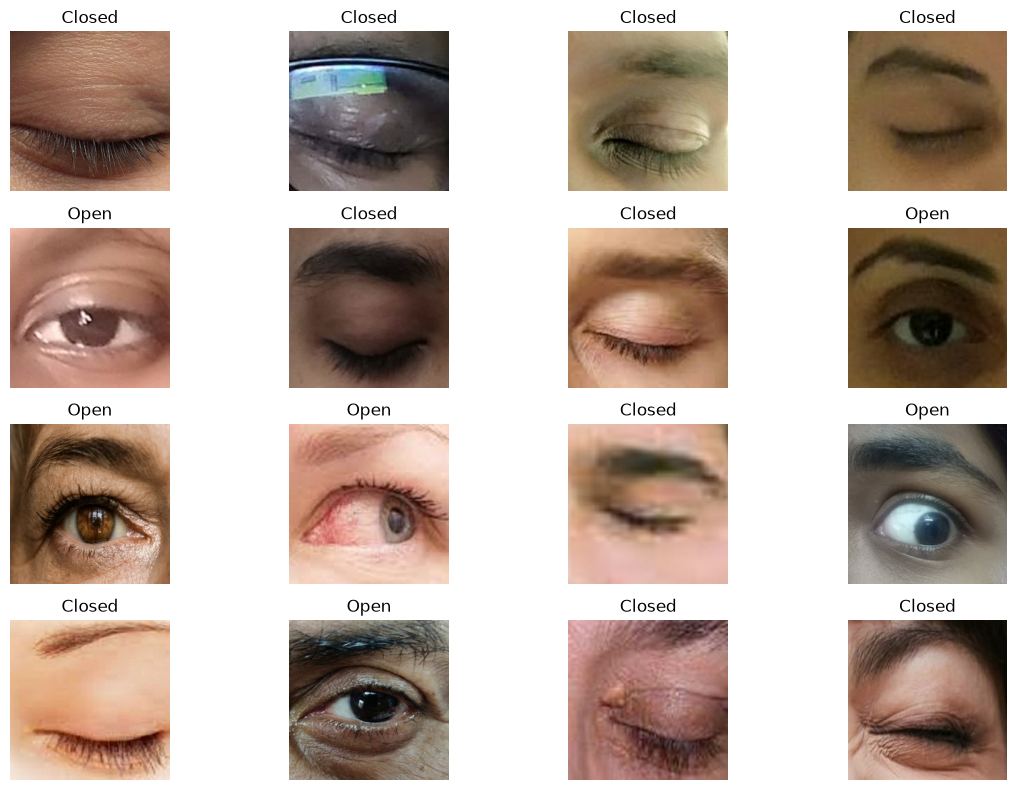

In [8]:
# 5. Display a batch of training images

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(16, len(images))):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()


In [9]:
# 6. Calculate class weights

train_labels = []

for _, labels in train_ds:
    train_labels.extend(labels.numpy().tolist())

train_labels = np.array(train_labels)

classes = np.arange(NUM_CLASSES)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, weights)
}

print("Class weights:", class_weights)

print("\nTraining label counts:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"{idx} - {name}: {(train_labels == idx).sum()}")


Class weights: {0: 0.9865384615384616, 1: 1.0138339920948616}

Training label counts:
0 - Closed: 520
1 - Open: 506


## 7. Conservative training augmentation




In [10]:
# 7. Data augmentation

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomContrast(0.10),
    ],
    name="eye_training_augmentation"
)

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


 Custom CNN 



This remains a genuine CNN trained from scratch; it does not use ImageNet weights.


In [ ]:
# 8. Build Custom CNN 

def conv_block(x, filters, block_name):
    x = tf.keras.layers.Conv2D(
        filters,
        (3, 3),
        padding="same",
        use_bias=False,
        name=f"{block_name}_conv1"
    )(x)
    x = tf.keras.layers.BatchNormalization(
        name=f"{block_name}_bn1"
    )(x)
    x = tf.keras.layers.ReLU(
        name=f"{block_name}_relu1"
    )(x)

    x = tf.keras.layers.Conv2D(
        filters,
        (3, 3),
        padding="same",
        use_bias=False,
        name=f"{block_name}_conv2"
    )(x)
    x = tf.keras.layers.BatchNormalization(
        name=f"{block_name}_bn2"
    )(x)
    x = tf.keras.layers.ReLU(
        name=f"{block_name}_relu2"
    )(x)

    x = tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        name=f"{block_name}_pool"
    )(x)

    return x


inputs = tf.keras.Input(
    shape=(*IMG_SIZE, 3),
    name="eye_input"
)

x = data_augmentation(inputs)

x = conv_block(x, 32, "block1")
x = conv_block(x, 64, "block2")
x = conv_block(x, 128, "block3")

# Final block without pooling so more spatial information is retained
x = tf.keras.layers.Conv2D(
    256, (3, 3), padding="same", use_bias=False,
    name="block4_conv1"
)(x)
x = tf.keras.layers.BatchNormalization(name="block4_bn1")(x)
x = tf.keras.layers.ReLU(name="block4_relu1")(x)

x = tf.keras.layers.Conv2D(
    256, (3, 3), padding="same", use_bias=False,
    name="block4_conv2"
)(x)
x = tf.keras.layers.BatchNormalization(name="block4_bn2")(x)
x = tf.keras.layers.ReLU(name="block4_relu2")(x)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu",
    name="dense_128"
)(x)

x = tf.keras.layers.Dropout(
    0.40,
    name="dropout"
)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="eye_state_output"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="eye_state_custom_cnn_v2"
)

model.summary()


Model: "eye_state_custom_cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eye_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ eye_training_augmentation       │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (ReLU)             │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (ReLU)             │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (ReLU)             │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (ReLU)             │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (ReLU)             │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (ReLU)             │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,208,290 (4.61 MB)

 Trainable params: 1,206,370 (4.60 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [12]:
# 9. Compile model

optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4
)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False
)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

print("Optimizer:", optimizer)
print("Initial learning rate: 1e-4")


Optimizer: <keras.src.optimizers.adam.Adam object at 0x0000029F54E02F10>
Initial learning rate: 1e-4


## 10. Training callbacks




In [13]:
# 10. Callbacks

model_path = MODEL_DIR / "eye_custom_cnn_v2_best.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(model_path),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]


## 11. Train Custom CNN v2

In [14]:
# 11. Train

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40


d:\driver-drowsiness-detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6316 - loss: 0.6743
Epoch 1: val_loss improved from None to 0.69562, saving model to d:\driver-drowsiness-detection\models\eye_custom_cnn_v2_best.keras

Epoch 1: finished saving model to d:\driver-drowsiness-detection\models\eye_custom_cnn_v2_best.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 198s 6s/step - accuracy: 0.6316 - loss: 0.6743 - val_accuracy: 0.4858 - val_loss: 0.6956 - learning_rate: 1.0000e-04
Epoch 2/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6852 - loss: 0.5929
Epoch 2: val_loss did not improve from 0.69562
33/33 ━━━━━━━━━━━━━━━━━━━━ 243s 7s/step - accuracy: 0.6852 - loss: 0.5929 - val_accuracy: 0.4953 - val_loss: 0.7180 - learning_rate: 1.0000e-04
Epoch 3/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7856 - loss: 0.4936
Epoch 3: val_loss did not improve from 0.69562
33/33 ━━━━━━━━━━━━━━━━━━━━ 268s 8s/step - accuracy: 0.7856 - loss: 0.4936 - val_accuracy: 0.4906 - val_loss: 0.7820 - learning_rate: 1.0000e-04
Ep

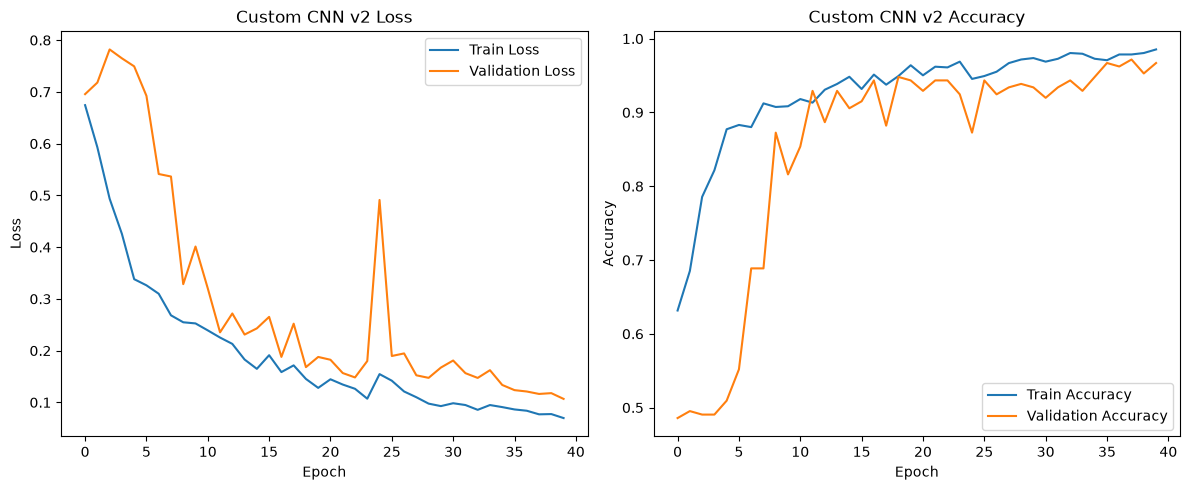

In [15]:
# 12. Plot training history

history_df = pd.DataFrame(history.history)

fig = plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN v2 Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN v2 Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


## 13. Test evaluation



In [16]:
# 13. Collect test predictions

y_true = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_prob.append(probs)
    y_true.extend(labels.numpy().tolist())

y_true = np.array(y_true)
y_prob = np.concatenate(y_prob, axis=0)
y_pred = np.argmax(y_prob, axis=1)

accuracy = accuracy_score(y_true, y_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Test Accuracy        : {accuracy:.4f}")
print(f"Macro Precision      : {precision_macro:.4f}")
print(f"Macro Recall         : {recall_macro:.4f}")
print(f"Macro F1             : {f1_macro:.4f}")
print(f"Weighted Precision   : {precision_weighted:.4f}")
print(f"Weighted Recall      : {recall_weighted:.4f}")
print(f"Weighted F1          : {f1_weighted:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


Test Accuracy        : 0.9626
Macro Precision      : 0.9624
Macro Recall         : 0.9634
Macro F1             : 0.9626
Weighted Precision   : 0.9633
Weighted Recall      : 0.9626
Weighted F1          : 0.9626

Classification Report:
              precision    recall  f1-score   support

      Closed     0.9434    0.9804    0.9615       102
        Open     0.9815    0.9464    0.9636       112

    accuracy                         0.9626       214
   macro avg     0.9624    0.9634    0.9626       214
weighted avg     0.9633    0.9626    0.9626       214



Confusion Matrix:
[[100   2]
 [  6 106]]


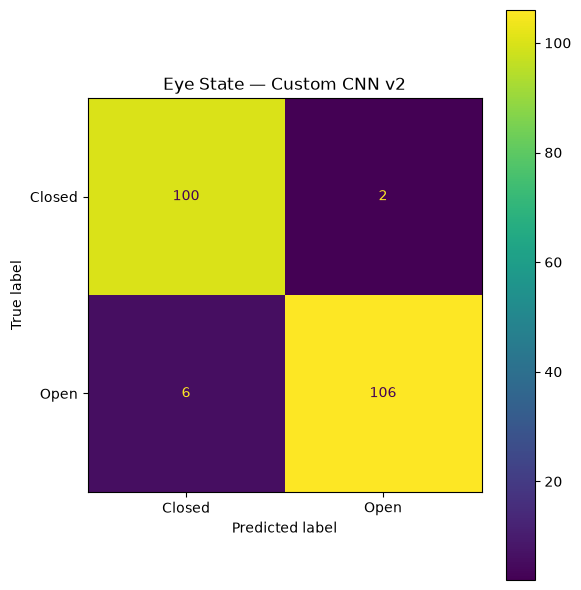

In [17]:
# 14. Confusion matrix

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

print("Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title("Eye State — Custom CNN v2")
plt.tight_layout()
plt.show()


Mean confidence   : 0.9436
Median confidence : 0.9837
Min confidence    : 0.5016
Max confidence    : 0.9999


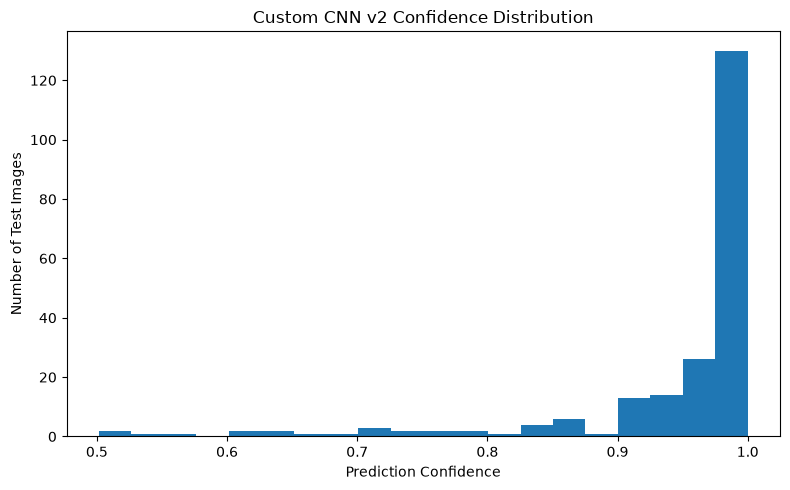

In [18]:
# 15. Confidence analysis

confidence = np.max(y_prob, axis=1)

print(f"Mean confidence   : {confidence.mean():.4f}")
print(f"Median confidence : {np.median(confidence):.4f}")
print(f"Min confidence    : {confidence.min():.4f}")
print(f"Max confidence    : {confidence.max():.4f}")

plt.figure(figsize=(8, 5))
plt.hist(confidence, bins=20)
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Test Images")
plt.title("Custom CNN v2 Confidence Distribution")
plt.tight_layout()
plt.show()


In [20]:
# 17. Per-class metrics table

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

per_class_df = pd.DataFrame(report).T

display(
    per_class_df.loc[
        CLASS_NAMES,
        ["precision", "recall", "f1-score", "support"]
    ]
)


,precision,recall,f1-score,support
Closed,0.943396,0.980392,0.961538,102.0
Open,0.981481,0.946429,0.963636,112.0


## 18. Save metrics



In [21]:
# 18. Save metrics and configuration

metrics = {
    "model_name": "eye_state_custom_cnn_v2",
    "input_size": list(IMG_SIZE),
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "batch_size": BATCH_SIZE,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history.history["loss"]),
    "optimizer": "Adam",
    "initial_learning_rate": 1e-4,
    "label_smoothing": 0.0,
    "augmentation": {
        "horizontal_flip": True,
        "rotation_factor": 0.05,
        "zoom_factor": 0.10,
        "contrast_factor": 0.10
    },
    "dropout": 0.40,
    "class_weights": class_weights,
    "test_metrics": {
        "accuracy": float(accuracy),
        "macro_precision": float(precision_macro),
        "macro_recall": float(recall_macro),
        "macro_f1": float(f1_macro),
        "weighted_precision": float(precision_weighted),
        "weighted_recall": float(recall_weighted),
        "weighted_f1": float(f1_weighted)
    },
    "confusion_matrix": cm.tolist(),
    "confidence": {
        "mean": float(confidence.mean()),
        "median": float(np.median(confidence)),
        "min": float(confidence.min()),
        "max": float(confidence.max())
    }
}

metrics_path = OUTPUT_DIR / "eye_custom_cnn_v2_metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Saved model:", model_path)
print("Saved metrics:", metrics_path)


Saved model: d:\driver-drowsiness-detection\models\eye_custom_cnn_v2_best.keras
Saved metrics: d:\driver-drowsiness-detection\outputs\eye_custom_cnn_v2_metrics.json
